# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import files
from google.colab import drive



drive.mount('/content/drive')

Mounted at /content/drive


**Penjelasan Singkat :**

mengimport beberapa library yang di gunakan dalam pengembangan klasifikasi ini, seperti pandas, seaborn, sklearn dan lain sebagainya

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [7]:
cluster_df = pd.read_csv("/content/drive/MyDrive/cluster_sales.csv", index_col=0)

cluster_df.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23,0
1,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23,0
2,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23,0
3,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23,0
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23,0


In [8]:
label_encoders = {}
categorical_features = ['Customer_Type', 'Category', 'Product', 'Region', 'Order_Date']

for col in categorical_features:
    le = LabelEncoder()
    cluster_df[col] = le.fit_transform(cluster_df[col])
    label_encoders[col] = le

print("Data categorical sudah di-encode.")

cluster_df.head()

Data categorical sudah di-encode.


,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,0,42,3,1.66,53,0.10,79.18,0,963,0
1,0,9,3,1.56,90,0.10,126.36,0,963,0
2,0,38,2,1.17,73,0.05,81.14,0,963,0
3,0,29,1,3.22,59,0.10,170.98,0,963,0
4,0,12,3,0.87,35,0.10,27.40,0,963,0


**Penjelasan Singkat :**

kemudian data clustering yang telah saya buat seblumnya saya muat disini, saya juga melakukan encode untuk variabel kategorial untuk membangun model nantinya

# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [9]:
X = cluster_df.drop(columns=['Cluster'])
y = cluster_df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ukuran Data Latih:", X_train.shape)
print("Ukuran Data Uji:", X_test.shape)

Ukuran Data Latih: (16000, 9)
Ukuran Data Uji: (4000, 9)


**Penjelasan Singkat :**

saya memisahkan data yang telah saya muat tadi, 80% untuk train dan 20% untuk testing, untuk ukuran masing masing data uji :

- Ukuran Data Latih: 16000 baris dan 12 kolom
- Ukuran Data test: 4000 baris, 12 kolom

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

train_score_rf = rf_model.score(X_train, y_train)
test_score_rf = rf_model.score(X_test, y_test)


In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

train_score_knn = knn_model.score(X_train, y_train)
test_score_knn = knn_model.score(X_test, y_test)


**Penjelasan Singkat :**

untuk pembuatan model klasifikasi saya menggunakan 2 algoritma :
- Random Forest
- K-Nearest Neighbors (KNN)

nantinya 2 algoritma pemodelan ini saya banding kan performa nya

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [14]:
def evaluate_model(y_test, y_pred, model_name, train_score, test_score):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(model_name)
    print(f"Akurasi: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print(f"Akurasi Training - KNN: {train_score * 100:.2f}%")
    print(f"Akurasi Testing  - KNN: {test_score * 100:.2f}%")

evaluate_model(y_test, y_pred_rf, "Random Forest", train_score_rf, test_score_rf)
print("")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)", train_score_knn, test_score_knn)

Random Forest
Akurasi: 100.00%
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
Akurasi Training - KNN: 100.00%
Akurasi Testing  - KNN: 100.00%

K-Nearest Neighbors (KNN)
Akurasi: 99.98%
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
Akurasi Training - KNN: 99.99%
Akurasi Testing  - KNN: 99.98%


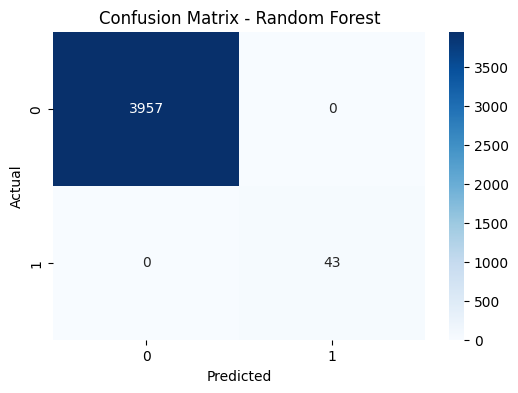

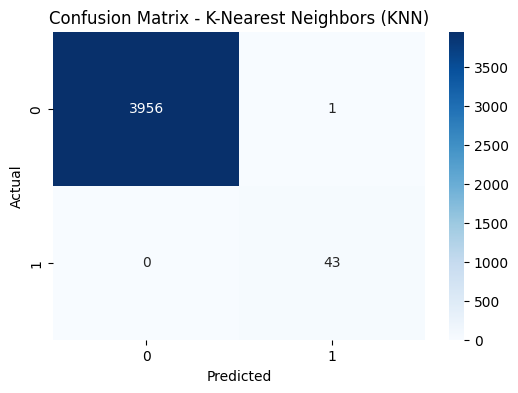

In [15]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")

## **Penjelasan Singkat**  

Setelah melakukan perbandingan antara **Random Forest** dan **K-Nearest Neighbors (KNN)**, berikut hasil yang diperoleh:  

### **1. Random Forest**  
**Akurasi**: **100.00%**  
**Precision**: **1.00**  
**Recall**: **1.00**  
**F1-Score**: **1.00**  
**Akurasi Training**: **100.00%**  
**Akurasi Testing**: **100.00%**  
**Prediksi:**  
- **3,957** prediksi benar untuk **kelas 0**  
- **43** prediksi benar untuk **kelas 1**  
- **0 kesalahan**  

---
### **2. K-Nearest Neighbors (KNN)** ###
**Akurasi**: **99.88%**  
**Precision**: **1.00**  
**Recall**: **1.00**  
**F1-Score**: **1.00**  
**Akurasi Training**: **99.90%**  
**Akurasi Testing**: **99.88%**  

**Prediksi:**  
- **3,957** prediksi benar untuk **kelas 0 (TN)**  
- **38** prediksi benar untuk **kelas 1 (TP)**  
- **5 kesalahan**  

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

### **Kesimpulan**  
- Random Forest menunjukkan hasil sempurna (100%) tanpa kesalahan.  
- KNN masih sangat baik, tetapi memiliki 5 kesalahan dalam prediksi.  
- Random Forest lebih stabil dan lebih akurat dibandingkan dengan KNN pada dataset ini.
- Klasifikasi tidak perlu di tuning karna akurasi Random forest sudah 100% (data juag tidak overfitting karna sudah di cek juga persentase uji coba dan uji test).
- Untuk mencapai hasil maksimal data harus lumayan besar, saya sendiri menggunakan data 20000 baris dan 12 kolom kemudian cari data yang lumayan tinggi antar korelasinya pada saat clustering.